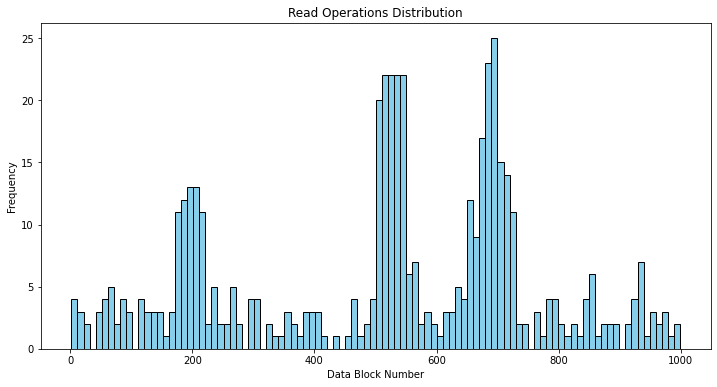

(8.36954968455824, 0.2026298342541436)

In [2]:
import random
import matplotlib.pyplot as plt
import numpy as np

# 数据块数量
num_blocks = 1000

# 生成顺序读操作
sequential_reads = []
for i in range(5):  # 5 个顺序段
    start_block = random.randint(0, num_blocks - 51)
    sequential_reads.extend(range(start_block, start_block + 50))

# 生成随机读操作
random_reads = [random.randint(0, num_blocks - 1) for _ in range(250)]

# 合并所有读操作
all_reads = sequential_reads + random_reads

# 分析随机度
unique_blocks, counts = np.unique(all_reads, return_counts=True)

# 熵计算
entropy = -np.sum((counts / len(all_reads)) * np.log2(counts / len(all_reads)))

# 基尼系数计算
sorted_counts = np.sort(counts)
cumulative_counts = np.cumsum(sorted_counts)
gini_coefficient = 1 - 2 * np.sum(cumulative_counts) / (len(counts) * cumulative_counts[-1])

# 可视化读操作的分布
plt.figure(figsize=(12, 6))
plt.hist(all_reads, bins=100, color='skyblue', edgecolor='black')
plt.title("Read Operations Distribution")
plt.xlabel("Data Block Number")
plt.ylabel("Frequency")
plt.show()

entropy, gini_coefficient